Dataset Loaded Successfully
Shape of Dataset: (891, 12)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  

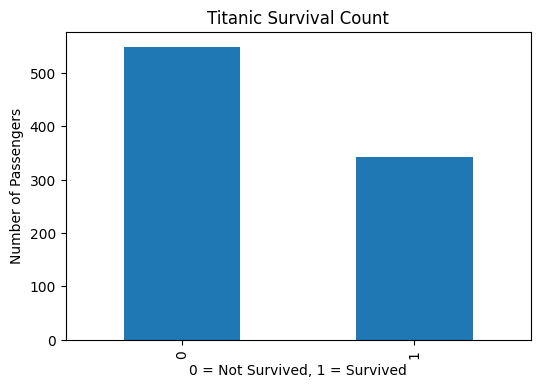

<Figure size 600x400 with 0 Axes>

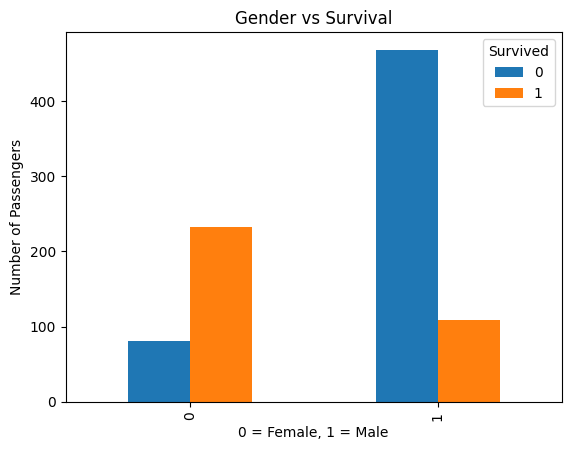

<Figure size 600x400 with 0 Axes>

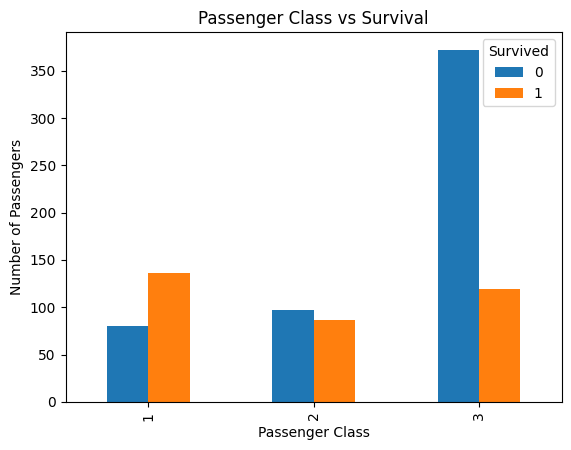

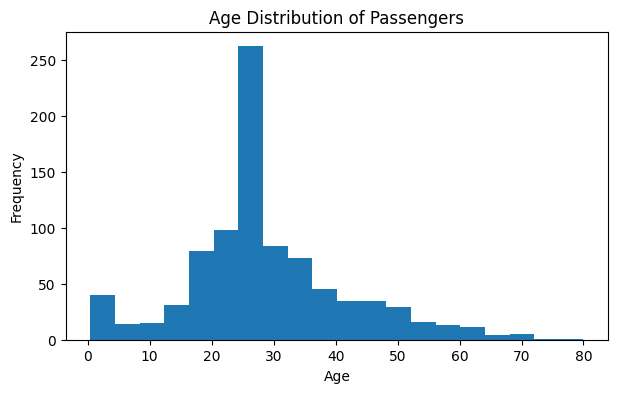


Feature Importance:
    Feature  Importance
1       Sex    0.271410
5      Fare    0.265010
2       Age    0.249995
0    Pclass    0.086957
3     SibSp    0.053685
4     Parch    0.039897
6  Embarked    0.033044


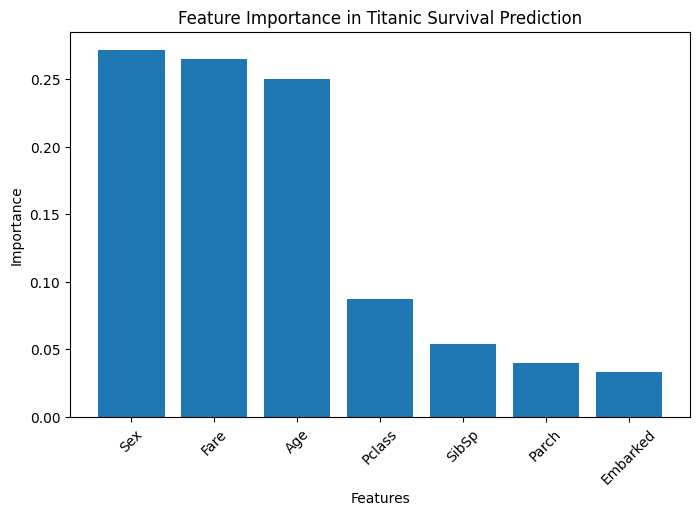


Sample Passenger Data:
   Pclass  Sex  Age  SibSp  Parch  Fare  Embarked
0       3    1   22      1      0  7.25         2
Prediction: Passenger Did Not Survive


In [2]:
# CODSOFT Data Science Internship
# Task 1: Titanic Survival Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Dataset
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset Loaded Successfully")
print("Shape of Dataset:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# 2. Data Cleaning
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop columns not useful for model
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# 3. Encode Categorical Columns
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

print("\nCleaned Dataset:")
print(df.head())

# 4. Feature Selection
X = df.drop("Survived", axis=1)
y = df["Survived"]

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# 6. Model Training
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed Successfully")

# 7. Prediction
y_pred = model.predict(X_test)

# 8. Model Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9. Survival Count Chart
plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Titanic Survival Count")
plt.xlabel("0 = Not Survived, 1 = Survived")
plt.ylabel("Number of Passengers")
plt.show()

# 10. Gender vs Survival Chart
plt.figure(figsize=(6,4))
pd.crosstab(df["Sex"], df["Survived"]).plot(kind="bar")
plt.title("Gender vs Survival")
plt.xlabel("0 = Female, 1 = Male")
plt.ylabel("Number of Passengers")
plt.show()

# 11. Passenger Class vs Survival Chart
plt.figure(figsize=(6,4))
pd.crosstab(df["Pclass"], df["Survived"]).plot(kind="bar")
plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

# 12. Age Distribution Chart
plt.figure(figsize=(7,4))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# 13. Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance in Titanic Survival Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

# 14. Sample Prediction
sample_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": [1],        # 0 = Female, 1 = Male
    "Age": [22],
    "SibSp": [1],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": [2]
})

sample_prediction = model.predict(sample_passenger)

print("\nSample Passenger Data:")
print(sample_passenger)

if sample_prediction[0] == 1:
    print("Prediction: Passenger Survived")
else:
    print("Prediction: Passenger Did Not Survive")